# GROUP PROJECT

**IMPORTANT from classes**

* try remove shit data: create 3 folds and record on what photos model fails - they are the condidats to be removed
* try ebmedinng model and find outliers in that space for each cluster
* mb try base models from hugging face 

* use tensorboard
* add a heatmap on top of image at the end
* plot the closest images

## Importing libraries

In [1]:
#
import numpy as np
import pandas as pd

# Data visualisation
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# sklearn related
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

#
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import L1, L2
#
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from keras.layers import Input, Dense, Dropout
from keras.optimizers import Adam, SGD, Adagrad, Adadelta, RMSprop
from keras.utils import to_categorical

# cnn related
from keras.layers import Conv2D, Flatten, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization




# sort later :3
import tensorflow as tf
import math
from collections import Counter
from PIL import Image as PilImage

# manipulating files
import cv2
from tqdm import tqdm
import os
import ast

# For image showing
from IPython.display import Image, display
import matplotlib.pyplot as plt
import os

# Import pretrained model   
from tensorflow.keras.applications import EfficientNetB4 
from tensorflow.keras.applications.efficientnet import preprocess_input

In [2]:
# Import custom functions
from custom_function import * 
%load_ext autoreload
%autoreload 2

In [3]:
directory = 'rare_species/'

In [4]:
# Cheak if GPU is detected
print("GPUs detected:", tf.config.list_physical_devices('GPU'))

GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
metadata = pd.read_csv(f'{directory}metadata.csv')

## Data exploration

### Metadata exploration

#### Basic exploration

In [6]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11983 entries, 0 to 11982
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   rare_species_id  11983 non-null  object
 1   eol_content_id   11983 non-null  int64 
 2   eol_page_id      11983 non-null  int64 
 3   kingdom          11983 non-null  object
 4   phylum           11983 non-null  object
 5   family           11983 non-null  object
 6   file_path        11983 non-null  object
dtypes: int64(2), object(5)
memory usage: 655.4+ KB


In [7]:
metadata.head()

,rare_species_id,eol_content_id,eol_page_id,kingdom,phylum,family,file_path
0,75fd91cb-2881-41cd-88e6-de451e8b60e2,12853737,449393,animalia,mollusca,unionidae,mollusca_unionidae/12853737_449393_eol-full-si...
1,28c508bc-63ff-4e60-9c8f-1934367e1528,20969394,793083,animalia,chordata,geoemydidae,chordata_geoemydidae/20969394_793083_eol-full-...
2,00372441-588c-4af8-9665-29bee20822c0,28895411,319982,animalia,chordata,cryptobranchidae,chordata_cryptobranchidae/28895411_319982_eol-...
3,29cc6040-6af2-49ee-86ec-ab7d89793828,29658536,45510188,animalia,chordata,turdidae,chordata_turdidae/29658536_45510188_eol-full-s...
4,94004bff-3a33-4758-8125-bf72e6e57eab,21252576,7250886,animalia,chordata,indriidae,chordata_indriidae/21252576_7250886_eol-full-s...


In [8]:
metadata.describe(include='O')

,rare_species_id,kingdom,phylum,family,file_path
count,11983,11983,11983,11983,11983
unique,11983,1,5,202,11983
top,75fd91cb-2881-41cd-88e6-de451e8b60e2,animalia,chordata,cercopithecidae,mollusca_unionidae/12853737_449393_eol-full-si...
freq,1,11983,9952,300,1


In [9]:
plot_phylum_counts(metadata)

In [10]:
plot_family_counts(metadata)

In [11]:
# Count at each taxonomic level
phylum_to_family = metadata.groupby(['phylum', 'family']).size().reset_index(name='count')

# Prepare data for Sankey
labels = list(metadata['phylum'].unique()) + list(metadata['family'].unique())
label_dict = {label: idx for idx, label in enumerate(labels)}

source = []
target = []
value = []

for _, row in phylum_to_family.iterrows():
    source.append(label_dict[row['phylum']])
    target.append(label_dict[row['family']])
    value.append(row['count'])

# Create Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
        color='#6366f1'
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color='rgba(99, 102, 241, 0.3)'
    )
)])

fig.update_layout(
    title='<b>Taxonomic Hierarchy: Phylum → Family</b>',
    font=dict(size=12),
    height=800,
    width=1200
)

fig.show()

print("\n📊 TAXONOMIC DIVERSITY:")
print(f"Phylums: {metadata['phylum'].nunique()}")
print(f"Families: {metadata['family'].nunique()}")
print(f"Average families per phylum: {metadata['family'].nunique() / metadata['phylum'].nunique():.1f}")


📊 TAXONOMIC DIVERSITY:
Phylums: 5
Families: 202
Average families per phylum: 40.4


#### Retracting more information from the images

In [12]:
# # Extract more information about the images and save to the metadata df (6min)
# metadata['image_size'], metadata['color_channel'], metadata['format'], metadata['aspect_ratio'], \
# metadata['min_val'], metadata['max_val'] = explore_image_files(directory + metadata['file_path'], explore_values=True)

# Don't explore values to save time (1min)
metadata['image_size'], metadata['color_channel'], metadata['format'], metadata['aspect_ratio'] = explore_image_files(directory + metadata['file_path'])

c:\Users\User\miniforge3\envs\dl\lib\site-packages\PIL\Image.py:3432: DecompressionBombWarning:

Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.



In [13]:
metadata['width'], metadata['height'] = zip(*metadata['image_size'])

In [14]:
metadata.describe()

,eol_content_id,eol_page_id,aspect_ratio,width,height
count,1.198300e+04,1.198300e+04,11983.000000,11983.000000,11983.000000
mean,2.297681e+07,2.112247e+07,1.332127,1924.600935,1512.260285
std,6.999289e+06,2.241319e+07,0.396398,1267.575315,951.330175
min,4.750000e+02,1.180080e+05,0.199919,170.000000,125.000000
25%,2.058937e+07,7.954560e+05,1.247341,1000.000000,768.000000
50%,2.251368e+07,2.865857e+06,1.333333,1784.000000,1365.000000
75%,2.932887e+07,4.551773e+07,1.500366,2048.000000,2013.500000
max,3.061946e+07,5.269200e+07,7.534247,17000.000000,8688.000000


huge file at "\rare_species\mollusca_cardiidae\30003931_46473744_eol-full-size-copy.jpg"

In [15]:
plot_color_chanels_counts(metadata)

In [16]:
# Based on previous discoveries set up potencial boudaries for image scaling
common_ratio = 4/3
width_max = 500       

In [17]:
plot_image_size_scatter(metadata, common_ratio, width_max)

In [18]:
# Calculate the final image size
image_size = (width_max, round(width_max/common_ratio))

### Images exploration

#### All images

In [19]:
# plot_images_from_directory(directory, img_per_class=5)

From plotting sample of the images we can see that have some unusial examples like:

- X-ray imagaes
- Images of signs
- Paintings
- Text extracts with no images
- Images unrelated to the class
- Maps
- Varying zoom / color / rotations

#### Grayscale and CMYK
Lets take a look at what are the different color formats

In [20]:
datagen = ImageDataGenerator(rescale=1./255)

# Get only greyscale images
temp_generator = datagen.flow_from_dataframe(
    dataframe=metadata[metadata.color_channel == 'L'],
    directory=directory,
    x_col='file_path',
    y_col='family',
    target_size=image_size,
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # Not shuffling
)

Found 183 validated image filenames belonging to 62 classes.


In [21]:
# plot_images_from_generator(temp_generator)

We can see that most of Grayscale images are sketches, drawings, x-rays or just old phorots. Some images retain at least the shape of the actual animal, but most of them are really bad.

In [22]:
# Do the same for CMYK
temp_generator = datagen.flow_from_dataframe(
    dataframe=metadata[metadata.color_channel == 'CMYK'],
    directory=directory,
    x_col='file_path',
    y_col='family',
    target_size=image_size,
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # Not shuffling
)

Found 178 validated image filenames belonging to 8 classes.


In [23]:
# plot_images_from_generator(temp_generator)

Most of the images apper to be x-rays of sculls of different types of monkeys and apes, which don't really help identify the animals by the picture, and will more likely only confuse the model. \
(and there are 2 different images for some reason: 1 with 2 parrots and another with a turtle)

In [24]:
# See what is the class distribution amoung the greyscale images
unique, counts = np.unique(temp_generator.classes, return_counts=True)
counts_per_class = dict(zip(unique, counts))

idx_to_class = {v: k for k, v in temp_generator.class_indices.items()}

for idx, count in counts_per_class.items():
    print(f"{idx_to_class[idx]}: {count} images")

aotidae: 36 images
atelidae: 27 images
callitrichidae: 30 images
cercopithecidae: 42 images
emydidae: 1 images
hominidae: 4 images
hylobatidae: 37 images
psittacidae: 1 images


## Preprocessing

### Calculate image embeddings

In [25]:
# Drop the CMYK images (only 2 actually valuable images)
metadata = metadata[metadata.color_channel != 'CMYK'].reset_index(drop=True)

In [26]:
# Load pre-trained EfficientNet without the top classification layer
embedding_model = EfficientNetB4(weights='imagenet', include_top=False, pooling='avg')
print(f"Embedding dimension: {embedding_model.output_shape[-1]}")

Embedding dimension: 1792


In [27]:
# Create generator with preprocessing form the model
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Create generator 
preprocessing_generator = datagen.flow_from_dataframe(
    dataframe=metadata,
    directory=directory,
    x_col='file_path',
    y_col='family',  
    target_size=image_size,
    batch_size=32,  
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False       # Not to mess up the order with df
)


# Generate embeddings
embeddings_list = []

# Calculate number of batches
num_batches = len(preprocessing_generator)

for i in tqdm(range(num_batches), desc="Embedding images"):  # Add a fancy progress bar
    batch_images, _ = next(preprocessing_generator)  # Get images (ignore labels)
    
    # Generate embeddings
    batch_embeddings = embedding_model.predict(batch_images, verbose=0) 
    embeddings_list.extend(batch_embeddings)

Found 11805 validated image filenames belonging to 202 classes.


Embedding images:  85%|████████▍ | 313/369 [03:49<01:01,  1.10s/it]c:\Users\User\miniforge3\envs\dl\lib\site-packages\PIL\Image.py:3432: DecompressionBombWarning:

Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.

Embedding images: 100%|██████████| 369/369 [04:27<00:00,  1.38it/s]


In [28]:
# Add embedings to metadata
metadata['embedding'] = embeddings_list

### Split the dataframe

In [29]:
# Stratified split the metadata to get the paths for the images
train_df, test_df = train_test_split(
  metadata,   # Use only good images
  test_size=0.1,
  stratify=metadata['family'],
  shuffle=True,
  random_state=42
)

### Remove inconsistencies

In [31]:
train_df['distance_to_centroid'], test_df['distance_to_centroid'] = distance_to_centroid(train_df, test_df)

In [ ]:
# plot_furthest_images_batched(directory, train_df, 200)

In [ ]:
# Identify outliers based on distance to centroid of the train_df
threshold = train_df['distance_to_centroid'].quantile(0.95) 

# Copy outliers in case we want them later for analysis
outliers_train = train_df[train_df['distance_to_centroid'] > threshold].copy()
outliers_test = test_df[test_df['distance_to_centroid'] > 1.1*threshold].copy()     # Allow a bit more different images to get into the test set

train_df = train_df[train_df['distance_to_centroid'] <= threshold].copy()
test_df = test_df[test_df['distance_to_centroid'] <= threshold].copy()

print(f"Removed {len(outliers_train)} outliers from train data")
print(f"Removed {len(outliers_test)} outliers from test data")

Removed 532 outliers from train data
Removed 22 outliers from test data


In [ ]:
# # Recalculate centroids
# train_df.drop('distance_to_centroid', axis=1, inplace=True)
# test_df.drop('distance_to_centroid', axis=1, inplace=True)
# train_df['distance_to_centroid'], test_df['distance_to_centroid'] = distance_to_centroid(train_df, test_df)

In [ ]:
# plot_furthest_images_batched(directory, train_df, 100)

In [ ]:
# # Identify outliers based on distance to centroid of the train_df
# threshold = train_df['distance_to_centroid'].quantile(0.95) 

# # Copy outliers in case we want them later for analysis
# outliers_train = pd.concat([outliers_train, train_df[train_df['distance_to_centroid'] > threshold]], ignore_index=True)
# outliers_test = pd.concat([outliers_test, test_df[test_df['distance_to_centroid'] > 1.1*threshold]], ignore_index=True)     # Allow a bit more different images to get into the test set

# train_df = train_df[train_df['distance_to_centroid'] <= threshold].copy()
# test_df = test_df[test_df['distance_to_centroid'] <= threshold].copy()

# print(f"Removed {len(outliers_train)} outliers from train data")
# print(f"Removed {len(outliers_test)} outliers from test data")

Total 1152 outliers


In [40]:
# See what class has the least images (save the family name for later)
low_images_class = train_df['family'].value_counts().idxmin()
print(f"Total images after removing inconsistencies: {len(train_df) + len(test_df)} (out of {len(metadata)})")
print(f"Images left for training: {len(train_df)}. Images left for testing: {len(test_df)}.")
print(f"The lowest amount of images per class is '{low_images_class}' with {train_df['family'].value_counts().iloc[-1]} images for training")

Total images after removing inconsistencies: 11209 (out of 11805)
Images left for training: 10092. Images left for testing: 1117.
The lowest amount of images per class is 'aotidae' with 21 images for training


In [45]:
# plot_furthest_images_batched(directory, train_df[train_df.family == low_images_class], 20)

In [ ]:
# plot_good_vs_bad_images(train_df, outliers_train, directory, good_images=2)

### Split and load the dataset

In [46]:
train_df, val_df = train_test_split(
  train_df,
  test_size=0.1,
  stratify=train_df['family'],
  shuffle=True,
  random_state=42
)

# Print the final proportions of the split
total_data_len = len(train_df) + len(val_df) + len(test_df)     # Amout of data after cleaning
print(f"Training  : {len(train_df)} ({round(len(train_df)/total_data_len*100)}%) \
        \nValidation: {len(val_df)} ({round(len(val_df)/total_data_len*100)}%)  \
        \nTesting   : {len(test_df)} ({round(len(test_df)/total_data_len*100)}%) \
        \nTotal     : {total_data_len}")

Training  : 9082 (81%)         
Validation: 1010 (9%)          
Testing   : 1117 (10%)         
Total     : 11209


In [113]:
# Set up train generator with data augmentatin and preprocessing
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.1,
    horizontal_flip=True,
    preprocessing_function=preprocess_input
)

# And the test generator with only the preprocessing
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [114]:
# Create train from train_datagen
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=directory,
    x_col='file_path',
    y_col='family',
    target_size=image_size,     # Transform to image_size
    batch_size=32,
    class_mode='sparse',        # Use sparse for integer labels
    color_mode='rgb',           # Convert all the images to RGB
    shuffle=True, 
    seed=42
)

# And validation and test from test_datagen
val_generator = datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=directory,
    x_col='file_path',
    y_col='family',
    target_size=image_size,
    batch_size=32,
    class_mode='sparse',  
    color_mode='rgb',
    shuffle=False, 
    seed=42
)

test_generator = datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=directory,
    x_col='file_path',
    y_col='family',
    target_size=image_size,
    batch_size=32,
    class_mode='sparse',  
    color_mode='rgb',
    shuffle=False,              # !! Not shuffling for reproducibility
    seed=42
    )

Found 9082 validated image filenames belonging to 202 classes.
Found 1010 validated image filenames belonging to 202 classes.
Found 1117 validated image filenames belonging to 202 classes.


## Modeling


In [115]:
N_CLASSES = len(train_generator.class_indices)
print(f"Number of classes: {N_CLASSES}")

Number of classes: 202


### Small custom model as baseline

In [ ]:
# # Build a small simple CNN my_model (1.5h+-)
# my_my_model = Sequential()
# my_model.add(Input((*image_size, 3)))

# # First Convolutional Block
# my_model.add(Conv2D(32, (3, 3), activation='relu'))
# my_model.add(BatchNormalization())
# my_model.add(MaxPooling2D((2, 2)))

# # Second Convolutional Block
# my_model.add(Conv2D(64, (3, 3), activation='relu'))
# my_model.add(BatchNormalization())
# my_model.add(MaxPooling2D((2, 2)))

# # Third Convolutional Block
# my_model.add(Conv2D(128, (3, 3), activation='relu'))
# my_model.add(BatchNormalization())
# my_model.add(MaxPooling2D((2, 2)))

# # Fourth Convolutional Block
# my_model.add(Conv2D(256, (3, 3), activation='relu'))
# my_model.add(BatchNormalization())
# my_model.add(MaxPooling2D((2, 2)))

# # Flatten and Dense Layers
# my_model.add(Flatten())

# my_model.add(Dense(512, activation='relu'))
# my_model.add(Dropout(0.3))
# my_model.add(Dense(256, activation='relu'))
# my_model.add(Dropout(0.3))
# my_model.add(Dense(N_CLASSES, activation='softmax'))

# # Compile the my_model
# my_model.compile(
#     optimizer='adam',
#     loss='sparce_categorical_crossentropy',
#     metrics=['accuracy']
# )


# # Define callbacks
# early_stopping = EarlyStopping(
#     monitor='val_loss',
#     patience=8,
#     restore_best_weights=True
# )

# reduce_lr = ReduceLROnPlateau(
#     monitor='val_loss',
#     factor=0.2,
#     patience=5,
#     min_lr=1e-7
# )

# # Train the my_model
# history_my = my_model.fit(
#     train_generator,
#     epochs=20,
#     batch_size=300,
#     validation_data=val_generator,
#     callbacks=[early_stopping, reduce_lr]
# )

Epoch 1/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 269s 862ms/step - accuracy: 0.0139 - loss: 12.2118 - val_accuracy: 0.0222 - val_loss: 5.2619 - learning_rate: 0.0010
Epoch 2/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 256s 843ms/step - accuracy: 0.0210 - loss: 5.2756 - val_accuracy: 0.0250 - val_loss: 5.2159 - learning_rate: 0.0010
Epoch 3/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 258s 847ms/step - accuracy: 0.0243 - loss: 5.2246 - val_accuracy: 0.0250 - val_loss: 5.1776 - learning_rate: 0.0010
Epoch 4/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 251s 827ms/step - accuracy: 0.0277 - loss: 5.1724 - val_accuracy: 0.0195 - val_loss: 5.5622 - learning_rate: 0.0010
Epoch 5/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 245s 807ms/step - accuracy: 0.0270 - loss: 5.1368 - val_accuracy: 0.0250 - val_loss: 5.1206 - learning_rate: 0.0010
Epoch 6/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 245s 808ms/step - accuracy: 0.0272 - loss: 5.1177 - val_accuracy: 0.0250 - val_loss: 5.1007 - learning_rate: 0.0010
Epoch 7/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 240s 789ms/step - accur

### Transfer learning with keras base model

#### EfficientNetB4

In [ ]:
# 

In [117]:
# Get the base model set up
base_model_B4 = EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_shape=(*image_size, 3) 
)

# Freeze base model initially
base_model_B4.trainable = False

In [54]:
# from focal_loss import SparseCategoricalFocalLoss

In [118]:
# Calculate the class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

In [119]:
# Build the classifier
with tf.device('/GPU:0'):   # Move the model to gpu
    modelB4 = Sequential([
        base_model_B4,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dropout(0.2),
        Dense(N_CLASSES, kernel_regularizer=L2(0.01), activation='softmax')
    ])

In [120]:
# See the parameter counts
print("Total params:", modelB4.count_params())
print("Non-trainable params:", sum([tf.size(w).numpy() for w in modelB4.non_trainable_weights]))
print("Trainable params:", sum([tf.size(w).numpy() for w in modelB4.trainable_weights]))

Total params: 18043177
Non-trainable params: 17677407
Trainable params: 365770


In [121]:
# Compile with categorical crossentropy for multi-class
modelB4.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',     
    metrics=['accuracy'] 
)

# Set up callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# Fit the model
historyB4 = modelB4.fit(
    train_generator,
    epochs=30,
    batch_size=350,
    class_weight=class_weight_dict,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
 33/284 [==>...........................] - ETA: 6:29 - loss: 8.1411 - accuracy: 0.1534

c:\Users\User\miniforge3\envs\dl\lib\site-packages\PIL\Image.py:3432: DecompressionBombWarning:

Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.



284/284 [==============================] - 483s 2s/step - loss: 4.4575 - accuracy: 0.5086 - val_loss: 3.1353 - val_accuracy: 0.6614 - lr: 0.0010
Epoch 2/30
284/284 [==============================] - 501s 2s/step - loss: 2.2655 - accuracy: 0.7136 - val_loss: 2.1951 - val_accuracy: 0.7079 - lr: 0.0010
Epoch 3/30
284/284 [==============================] - 484s 2s/step - loss: 1.7888 - accuracy: 0.7476 - val_loss: 1.9688 - val_accuracy: 0.7198 - lr: 0.0010
Epoch 4/30
284/284 [==============================] - 369s 1s/step - loss: 1.6353 - accuracy: 0.7515 - val_loss: 1.9770 - val_accuracy: 0.7040 - lr: 0.0010
Epoch 5/30
284/284 [==============================] - 427s 1s/step - loss: 1.6025 - accuracy: 0.7501 - val_loss: 1.9652 - val_accuracy: 0.7079 - lr: 0.0010
Epoch 6/30
284/284 [==============================] - 317s 1s/step - loss: 1.6203 - accuracy: 0.7518 - val_loss: 2.0104 - val_accuracy: 0.7069 - lr: 0.0010
Epoch 7/30
284/284 [==============================] - 532s 2s/step - loss: 

In [124]:
plot_model_results(historyB4, 'loss')

In [125]:
plot_model_results(historyB4, 'accuracy')

Because EfficientNetB4 is trained on millions of pictures it does not make sense to fine-tune it when we only have 15 images per some classes. But even if we wanted to try it is too heavy of model, and we would not able to fit in on the GPU even with a very small batch size.

#### EfficientNetB0

In [83]:
from tensorflow.keras.applications import EfficientNetB0

In [84]:
# Get the base model set up
base_model_B0 = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(*image_size, 3) 
)

# Freeze base model initially
base_model_B0.trainable = False

In [85]:
# Calculate the class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

In [86]:
# Add a data augmentation block with set seed
data_augmentation = Sequential([
    RandomFlip("horizontal", seed=42),
    RandomRotation(0.10, seed=42),
    RandomZoom(0.10, seed=42),
    RandomTranslation(0.1, 0.1, seed=42),
], name="data_augmentation")

In [87]:
# Build the classifier
with tf.device('/GPU:0'):   # Move the model to gpu
    modelB0 = Sequential([
        data_augmentation,
        Lambda(preprocess_input),
        base_model_B0,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dense(800, kernel_regularizer=L2(0.01)),
        Dropout(0.2),
        Dense(400, kernel_regularizer=L2(0.01)),
        Dropout(0.1),
        Dense(N_CLASSES, kernel_regularizer=L2(0.01), activation='softmax')
    ])

In [ ]:
# See the parameter counts
print("Total params:", modelB0.count_params())
print("Non-trainable params:", sum([tf.size(w).numpy() for w in modelB0.non_trainable_weights]))
print("Trainable params:", sum([tf.size(w).numpy() for w in modelB0.trainable_weights]))

In [89]:
# Compile with categorical crossentropy for multi-class
modelB0.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',     
    metrics=['accuracy'] 
)

# Set up callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# Fit the model
historyB0 = modelB0.fit(
    train_generator,
    epochs=15,
    batch_size=350,
    class_weight=class_weight_dict,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
250/284 [=========================>....] - ETA: 23s - loss: 15.5351 - accuracy: 0.3520

c:\Users\User\miniforge3\envs\dl\lib\site-packages\PIL\Image.py:3432: DecompressionBombWarning:

Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.



284/284 [==============================] - 227s 776ms/step - loss: 14.8134 - accuracy: 0.3660 - val_loss: 8.9584 - val_accuracy: 0.5297 - lr: 0.0010
Epoch 2/15
284/284 [==============================] - 224s 787ms/step - loss: 6.4612 - accuracy: 0.5139 - val_loss: 4.8695 - val_accuracy: 0.5218 - lr: 0.0010
Epoch 3/15
284/284 [==============================] - 226s 793ms/step - loss: 4.3218 - accuracy: 0.4894 - val_loss: 3.8828 - val_accuracy: 0.4980 - lr: 0.0010
Epoch 4/15
284/284 [==============================] - 242s 852ms/step - loss: 3.8009 - accuracy: 0.4707 - val_loss: 3.5939 - val_accuracy: 0.5149 - lr: 0.0010
Epoch 5/15
284/284 [==============================] - 244s 861ms/step - loss: 3.6688 - accuracy: 0.4533 - val_loss: 3.5242 - val_accuracy: 0.4871 - lr: 0.0010
Epoch 6/15
284/284 [==============================] - 232s 817ms/step - loss: 3.6305 - accuracy: 0.4442 - val_loss: 3.4632 - val_accuracy: 0.4762 - lr: 0.0010
Epoch 7/15
284/284 [==============================] - 26

In [90]:
plot_model_results(historyB0, 'loss')

In [91]:
plot_model_results(historyB0, 'accuracy')

#### Hyperband parameter search

In [106]:
from tensorflow import keras
import keras_tuner as kt

In [ ]:
def build_model(hp):

    # Get the base model set up
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(*image_size, 3) 
    )
    # Freeze base model initially
    base_model.trainable = False

    # Initialize sequential API and start building model.
    with tf.device('/GPU:0'):   # Move the model to gpu
        model = Sequential([
            base_model,
            GlobalAveragePooling2D(),
            BatchNormalization()
        ])


    # Tune the number of hidden layers and units in each.
    for i in range(1, hp.Int("num_layers", 2, 4)):  ## The basic for loop for including several layers
        model.add(
            keras.layers.Dense(
                units=hp.Int("units_" + str(i), min_value=300, max_value=1000, step=100),
                activation="relu")
            )
        # Dropout followin the previous dense layer means that after each layer we would have a dropout
        # Tune dropout layer with values from 0 - 0.3 with stepsize of 0.1.
        model.add(keras.layers.Dropout(hp.Float("dropout_" + str(i), 0, 0.4, step=0.1)))

    # Add output layer
    model.add(keras.layers.Dense(units=202, activation="softmax"))

    # Tune learning rate for Adam optimizer with values from 0.001, 0.0005 or 0.0001
    hp_learning_rate = hp.Choice("learning_rate", values=[1e-3, 5e-4, 1e-4])

    # Define optimizer, loss, and metrics
    model.compile(optimizer=Adam(learning_rate=hp_learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=["accuracy"])
    

    return model

In [ ]:
# Instantiate the tuner
tuner = kt.Hyperband(
    build_model,                # the model-building function
    objective='val_loss',       # the metric to optimise
    max_epochs=20,              # maximum number of epochs to train
    factor=3,                   # reduction factor for successive halving
    directory='keras_tuner',    # directory to save logs and results
    project_name='new-2'        # name of the project (creates a subfolder)
)

In [109]:
tuner.search_space_summary()

Search space summary
Default search space size: 4
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 2, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 300, 'max_value': 1000, 'step': 100, 'sampling': 'linear'}
dropout_1 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0005, 0.0001], 'ordered': True}


In [110]:
# Set up callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# Calculate the class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

In [111]:
tuner.search(train_generator, epochs=20, batch_size=350, class_weight=class_weight_dict, validation_data=val_generator, callbacks=[callbacks])

Trial 30 Complete [01h 18m 59s]
val_loss: 0.7352526187896729

Best val_loss So Far: 0.7240509390830994
Total elapsed time: 13h 41m 29s


In [112]:
best_hp=tuner.get_best_hyperparameters()[0]
print(best_hp.values)

{'num_layers': 2, 'units_1': 800, 'dropout_1': 0.1, 'learning_rate': 0.0001, 'units_2': 800, 'dropout_2': 0.2, 'units_3': 500, 'dropout_3': 0.4, 'tuner/epochs': 20, 'tuner/initial_epoch': 7, 'tuner/bracket': 1, 'tuner/round': 1, 'tuner/trial_id': '0021'}


So the final **best model** (to add on top of pretrained bone) is:

- One Dense layer with **800 neurons**

- Dropout of **0.1**

- And the learning rate of **0.0001**

#### Tuned model

In [126]:
# Get the base model set up
base_model_B0 = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(*image_size, 3) 
)

# Freeze base model initially
base_model_B0.trainable = False

In [127]:
# Calculate the class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

In [128]:
# Build the classifier
with tf.device('/GPU:0'):   # Move the model to gpu
    tuned_model = Sequential([
        base_model_B0,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dense(800),
        Dropout(0.1),
        Dense(N_CLASSES, activation='softmax')
    ])

In [129]:
# See the parameter counts
print("Total params:", tuned_model.count_params())
print("Non-trainable params:", sum([tf.size(w).numpy() for w in tuned_model.non_trainable_weights]))
print("Trainable params:", sum([tf.size(w).numpy() for w in tuned_model.trainable_weights]))

Total params: 5241293
Non-trainable params: 4052131
Trainable params: 1189162


In [130]:
# Compile with categorical crossentropy for multi-class
tuned_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',     
    metrics=['accuracy'] 
)

# Set up callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# Fit the model
history_tuned = tuned_model.fit(
    train_generator,
    epochs=40,
    batch_size=350,
    class_weight=class_weight_dict,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
109/284 [==========>...................] - ETA: 5:48 - loss: 5.0196 - accuracy: 0.0672

c:\Users\User\miniforge3\envs\dl\lib\site-packages\PIL\Image.py:3432: DecompressionBombWarning:

Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.



284/284 [==============================] - 609s 2s/step - loss: 3.8125 - accuracy: 0.2218 - val_loss: 2.4012 - val_accuracy: 0.4703 - lr: 1.0000e-04
Epoch 2/40
284/284 [==============================] - 473s 2s/step - loss: 1.7381 - accuracy: 0.5350 - val_loss: 1.5614 - val_accuracy: 0.5960 - lr: 1.0000e-04
Epoch 3/40
284/284 [==============================] - 461s 2s/step - loss: 1.2149 - accuracy: 0.6353 - val_loss: 1.3004 - val_accuracy: 0.6614 - lr: 1.0000e-04
Epoch 4/40
284/284 [==============================] - 482s 2s/step - loss: 0.9317 - accuracy: 0.7044 - val_loss: 1.1878 - val_accuracy: 0.6871 - lr: 1.0000e-04
Epoch 5/40
284/284 [==============================] - 479s 2s/step - loss: 0.7443 - accuracy: 0.7469 - val_loss: 1.0872 - val_accuracy: 0.7188 - lr: 1.0000e-04
Epoch 6/40
284/284 [==============================] - 477s 2s/step - loss: 0.6231 - accuracy: 0.7789 - val_loss: 1.0396 - val_accuracy: 0.7218 - lr: 1.0000e-04
Epoch 7/40
284/284 [==============================]

In [131]:
plot_model_results(history_tuned, 'loss')

In [132]:
plot_model_results(history_tuned, 'accuracy')

## Results

In [133]:
test_results = tuned_model.evaluate(test_generator, verbose=1)
print(f"Test Accuracy: {test_results[1]:.4f}")
print(f"Test Loss: {test_results[0]:.4f}")

35/35 [==============================] - 24s 678ms/step - loss: 0.8325 - accuracy: 0.7959
Test Accuracy: 0.7959
Test Loss: 0.8325


In [134]:
# Get predictions for F1 score
y_pred = tuned_model.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# Get true labels
y_true = test_generator.classes

# Calculate F1 scores
f1_micro = f1_score(y_true, y_pred_classes, average='micro')
f1_macro = f1_score(y_true, y_pred_classes, average='macro')
f1_weighted = f1_score(y_true, y_pred_classes, average='weighted')

print(f"\nF1 Score (Micro): {f1_micro:.4f}")
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")

#Detailed classification report
# print(classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices.keys()))
# The B4 results
# F1 Score (Micro): 0.8262
# F1 Score (Macro): 0.8032
# F1 Score (Weighted): 0.8242

35/35 [==============================] - 14s 373ms/step

F1 Score (Micro): 0.7959
F1 Score (Macro): 0.7867
F1 Score (Weighted): 0.7925


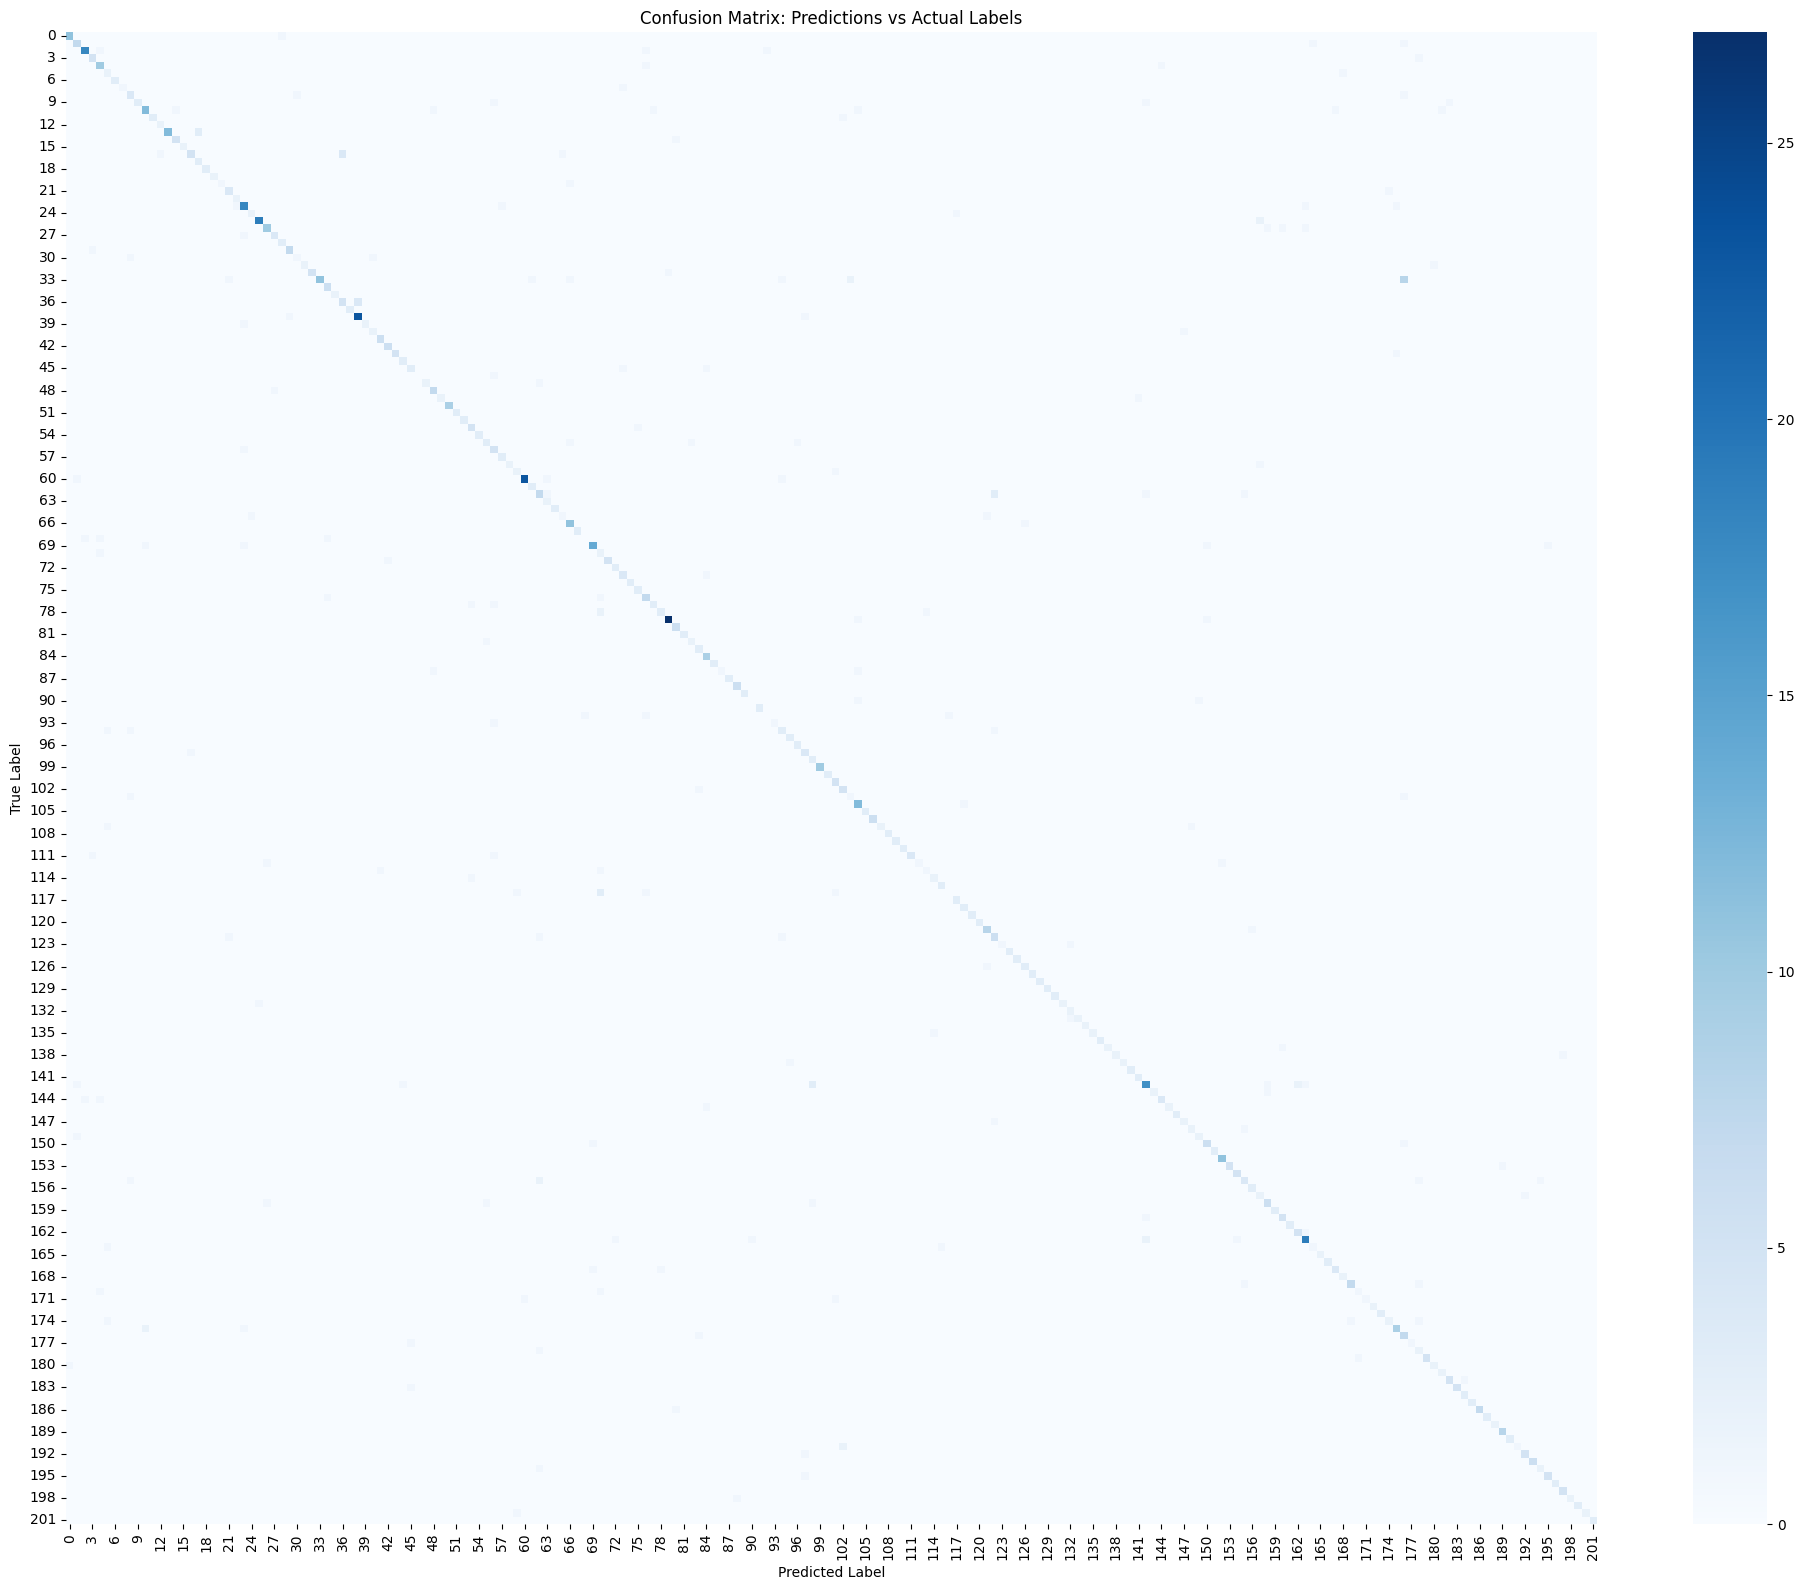

Confusion Matrix Shape: (202, 202)
Total Predictions: 1117


In [135]:
# Create confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', cbar=True)         # annot=np.where(cm > 0, cm, ""), annot_kws={"size": 5}
plt.title('Confusion Matrix: Predictions vs Actual Labels')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Print shape and summary
print(f"Confusion Matrix Shape: {cm.shape}")
print(f"Total Predictions: {cm.sum()}")

In [151]:
# y_pred_classes[1]
dict(test_generator.class_indices.items())[low_images_class]

46

In [136]:
def class_metrics(class_name):

    class_idx = test_generator.class_indices[class_name]

    TP = int(cm[class_idx, class_idx])
    FN = int(cm[class_idx, :].sum() - TP)   # actual positives missed
    FP = int(cm[:, class_idx].sum() - TP)   # predicted as this class but not actual
    TN = int(cm.sum() - (TP + FP + FN))
    support = TP + FN
    
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0   #per-class accuracy / sensitivity
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    class_accuracy = (TP + TN) / cm.sum()               # accuracy treating this class vs rest
    
    # class_name =idx_to_class[class_idx]
    print(f"Class: {class_name} (index={class_idx})")
    print(f" Support (true samples) : {support}")
    print(f" TP: {TP} | FN: {FN} | FP: {FP} | TN: {TN}")
    print(f" Precision : {precision:.4f}")
    print(f" Recall    : {recall:.4f}")     
    print(f" F1-score  : {f1:.4f}")
    print(f" Class-wise accuracy : {class_accuracy:.4f}")



In [137]:
class_metrics(low_images_class)

Class: aotidae (index=12)
 Support (true samples) : 2
 TP: 2 | FN: 0 | FP: 1 | TN: 1114
 Precision : 0.6667
 Recall    : 1.0000
 F1-score  : 0.8000
 Class-wise accuracy : 0.9991
